# Figure A2: Robustness to MAR Violations (Supplementary)

This notebook tests robustness of the MCAR-derived phase transition theory under
Missing At Random (MAR) mechanisms where missingness probability depends on observed values.

**Figure layout (3 panels):**
- (a) Phase transition curves under different MAR mechanisms (θ sweep at fixed mar_strength=0.5)
- (b) Theory deviation vs MAR strength (sweep mar_strength from 0 to 1)
- (c) 2D heatmap: empirical R_x² in (θ, mar_strength) space with MCAR theory boundary

In [15]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from multiprocessing import Pool
from tqdm.notebook import tqdm

from src import (
    ModelParams, generate_data_mar, pls_svd, compute_overlaps,
    theoretical_overlaps, run_multiple_trials_mar, _run_mar_worker, _run_mar_grid_worker
)

# ICML-compatible styling
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,  # TrueType fonts in PDF (avoids Type 3)
    'ps.fonttype': 42,   # TrueType fonts in PostScript
})

np.random.seed(42)

## 1. Define MAR Mechanisms

| Mechanism | Description | Effect |
|-----------|-------------|--------|
| MCAR (baseline) | Missingness independent of values | Theory exact |
| Signal-dependent | Miss prob ∝ |X @ u0| | Biases toward low-signal samples |
| Magnitude-dependent | Miss prob ∝ |X_ij| | Biases toward low-magnitude entries |
| Thresholded | High miss prob for |X_ij| > τ | Truncates tails |
| Correlated | Y missingness depends on X values | Cross-view dependency |

In [16]:
# MAR mechanism metadata
MAR_TYPES = {
    'signal_dependent': {
        'label': 'Signal-dependent',
        'color': 'C1',
        'marker': 's',
        'description': 'Miss prob increases with |X @ u0|',
    },
    'magnitude_dependent': {
        'label': 'Magnitude-dependent',
        'color': 'C2',
        'marker': '^',
        'description': 'Miss prob increases with |X_ij|',
    },
    'thresholded': {
        'label': 'Thresholded',
        'color': 'C3',
        'marker': 'v',
        'description': 'High miss prob for |X_ij| > 75th percentile',
    },
    'correlated': {
        'label': 'Correlated (X→Y)',
        'color': 'C4',
        'marker': 'd',
        'description': 'Y missingness depends on X latent',
    },
}

print("MAR mechanisms to test:")
for name, info in MAR_TYPES.items():
    print(f"  {info['label']:25s} - {info['description']}")

MAR mechanisms to test:
  Signal-dependent          - Miss prob increases with |X @ u0|
  Magnitude-dependent       - Miss prob increases with |X_ij|
  Thresholded               - High miss prob for |X_ij| > 75th percentile
  Correlated (X→Y)          - Y missingness depends on X latent


## 2. Experiment Setup

In [17]:
# Fixed parameters
N = 1000
Dx = 200
Dy = 150
mx_base = my_base = 0.3  # Base missingness rate
n_trials = 100

# Compute theta_crit (for MCAR theory)
alpha_x = N / Dx
alpha_y = N / Dy
rho = (1 - mx_base) * (1 - my_base)
theta_crit = 1 / ((alpha_x * alpha_y) ** 0.25 * np.sqrt(rho))

# Theta sweep
theta_values = np.linspace(0.5 * theta_crit, 2.0 * theta_crit, 25)

# MAR strength sweep
mar_strength_values = [0.0, 0.25, 0.5, 0.75, 1.0]

print(f"Parameters:")
print(f"  N={N}, Dx={Dx}, Dy={Dy}")
print(f"  mx_base={mx_base}, my_base={my_base}, ρ={(1-mx_base)*(1-my_base):.2f}")
print(f"  θ_crit = {theta_crit:.4f}")
print(f"  θ range: [{theta_values[0]:.3f}, {theta_values[-1]:.3f}]")
print(f"  MAR strength values: {mar_strength_values}")
print(f"  n_trials = {n_trials}")

Parameters:
  N=1000, Dx=200, Dy=150
  mx_base=0.3, my_base=0.3, ρ=0.49
  θ_crit = 0.5945
  θ range: [0.297, 1.189]
  MAR strength values: [0.0, 0.25, 0.5, 0.75, 1.0]
  n_trials = 100


## 3. Experiment A: Phase Transitions under Different MAR Mechanisms

For each MAR type, sweep θ at fixed mar_strength=0.5 and compare to MCAR theory.

In [18]:
# Check for cached results
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)
cache_file = os.path.join(results_dir, 'figA2_results.pkl')

if os.path.exists(cache_file):
    print("Loading cached results...")
    with open(cache_file, 'rb') as f:
        all_results = pickle.load(f)
    print("Done!")
else:
    print("Running experiments...")
    all_results = {'exp_a': {}, 'exp_b': {}, 'exp_c': {}}
    
    # Experiment A: theta sweep for each MAR type at mar_strength=0.5
    mar_strength_fixed = 0.5
    
    for mar_type in MAR_TYPES.keys():
        print(f"\n  Processing {MAR_TYPES[mar_type]['label']}...")
        
        args_list = []
        for theta in theta_values:
            params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta, 'mx': mx_base, 'my': my_base}
            args_list.append((params_dict, mar_type, mar_strength_fixed, n_trials, theta, theta_crit))
        
        with Pool() as pool:
            results = list(tqdm(pool.imap(_run_mar_worker, args_list),
                               total=len(args_list), desc=f"    θ sweep"))
        
        all_results['exp_a'][mar_type] = results
    
    # Experiment B: MAR strength sweep at fixed supercritical theta
    print("\n  Running MAR strength sweep...")
    theta_supercrit = 1.5 * theta_crit
    mar_strength_fine = np.linspace(0, 1, 20)
    
    for mar_type in MAR_TYPES.keys():
        print(f"    Processing {MAR_TYPES[mar_type]['label']}...")
        
        args_list = []
        for ms in mar_strength_fine:
            params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta_supercrit, 'mx': mx_base, 'my': my_base}
            args_list.append((params_dict, mar_type, ms, n_trials, theta_supercrit, theta_crit))
        
        with Pool() as pool:
            results = list(tqdm(pool.imap(_run_mar_worker, args_list),
                               total=len(args_list), desc=f"      strength sweep"))
        
        all_results['exp_b'][mar_type] = results
    all_results['exp_b']['mar_strength_values'] = mar_strength_fine
    
    # Experiment C: 2D grid (theta, mar_strength) for signal-dependent MAR
    print("\n  Running 2D grid experiment...")
    n_grid = 30
    theta_grid = np.linspace(0.5 * theta_crit, 2.0 * theta_crit, n_grid)
    mar_grid = np.linspace(0, 1, n_grid)
    
    args_list = []
    for i, theta in enumerate(theta_grid):
        for j, ms in enumerate(mar_grid):
            params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta, 'mx': mx_base, 'my': my_base}
            args_list.append((params_dict, 'signal_dependent', ms, 30, i, j))  # fewer trials for grid
    
    with Pool() as pool:
        grid_results = list(tqdm(pool.imap(_run_mar_grid_worker, args_list),
                                total=len(args_list), desc="    2D grid"))
    
    # Organize into 2D array
    Rx2_grid = np.zeros((n_grid, n_grid))
    for (i, j, rx2_emp, rx2_theory) in grid_results:
        Rx2_grid[i, j] = rx2_emp
    
    all_results['exp_c'] = {
        'Rx2_grid': Rx2_grid,
        'theta_grid': theta_grid,
        'mar_grid': mar_grid,
    }
    
    # Cache results
    with open(cache_file, 'wb') as f:
        pickle.dump(all_results, f)
    print("\nResults cached!")

Loading cached results...
Done!


## 4. Create Publication Figure

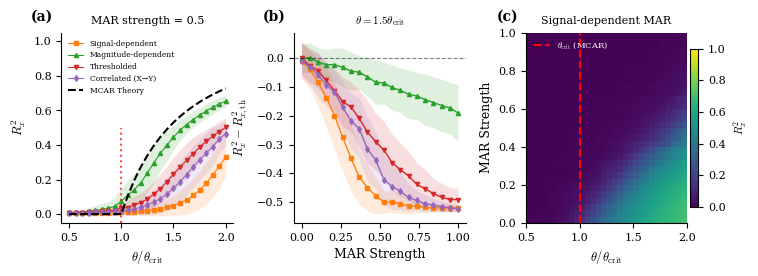


Figure saved: ../figures/figA2_mar_robustness.pdf


In [21]:
fig = plt.figure(figsize=(7.0, 2.5))
gs = gridspec.GridSpec(1, 3, wspace=0.35,
                       left=0.07, right=0.98, bottom=0.16, top=0.92)

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

# --- Panel (a): Phase transition curves under different MAR mechanisms ---
for mar_type, info in MAR_TYPES.items():
    results = all_results['exp_a'][mar_type]
    theta_norm = [r['theta_norm'] for r in results]
    rx2_mean = [r['Rx2_pls_mean'] for r in results]
    rx2_std = [r['Rx2_pls_std'] for r in results]
    
    ax_a.plot(theta_norm, rx2_mean,
              marker=info['marker'], markersize=3, linewidth=0.8,
              color=info['color'], label=info['label'])
    ax_a.fill_between(theta_norm,
                      np.array(rx2_mean) - np.array(rx2_std),
                      np.array(rx2_mean) + np.array(rx2_std),
                      color=info['color'], alpha=0.15, linewidth=0)

# MCAR Theory curve
results_first = all_results['exp_a'][list(MAR_TYPES.keys())[0]]
ax_a.plot([r['theta_norm'] for r in results_first],
          [r['Rx2_theory'] for r in results_first],
          'k--', linewidth=1.5, label='MCAR Theory', zorder=10)

ax_a.axvline(1.0, ymax=0.5, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax_a.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_a.set_ylabel(r'$R_x^2$')
ax_a.set_ylim([-0.05, 1.05])
ax_a.legend(loc='upper left', frameon=False, fontsize=5.5, ncol=1)
ax_a.set_title('MAR strength = 0.5', fontsize=8)
ax_a.text(-0.18, 1.12, '(a)', transform=ax_a.transAxes,
          fontsize=10, fontweight='bold', va='top')

# --- Panel (b): Theory deviation vs MAR strength ---
mar_strength_fine = all_results['exp_b']['mar_strength_values']

for mar_type, info in MAR_TYPES.items():
    results = all_results['exp_b'][mar_type]
    rx2_mean = [r['Rx2_pls_mean'] for r in results]
    rx2_std = [r['Rx2_pls_std'] for r in results]
    rx2_theory = [r['Rx2_theory'] for r in results]
    
    # Compute deviation from MCAR theory
    deviation = np.array(rx2_mean) - np.array(rx2_theory)
    
    ax_b.plot(mar_strength_fine, deviation,
              marker=info['marker'], markersize=3, linewidth=1,
              color=info['color'], label=info['label'])
    ax_b.fill_between(mar_strength_fine,
                      deviation - np.array(rx2_std),
                      deviation + np.array(rx2_std),
                      color=info['color'], alpha=0.15, linewidth=0)

ax_b.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
ax_b.set_xlabel('MAR Strength')
ax_b.set_ylabel(r'$R_x^2 - R_{x,\mathrm{th}}^2$')
ax_b.set_xlim([-0.05, 1.05])
# ax_b.legend(loc='lower left', frameon=False, fontsize=5.5)
ax_b.set_title(r'$\theta = 1.5\theta_{\mathrm{crit}}$', fontsize=8)
ax_b.text(-0.18, 1.12, '(b)', transform=ax_b.transAxes,
          fontsize=10, fontweight='bold', va='top')

# --- Panel (c): 2D heatmap (theta, mar_strength) ---
Rx2_grid = all_results['exp_c']['Rx2_grid']
theta_grid = all_results['exp_c']['theta_grid']
mar_grid = all_results['exp_c']['mar_grid']

# Note: imshow expects (row, col) = (y, x), so we transpose
# theta on x-axis, mar_strength on y-axis
extent = [theta_grid[0]/theta_crit, theta_grid[-1]/theta_crit,
          mar_grid[0], mar_grid[-1]]

im = ax_c.imshow(Rx2_grid.T, origin='lower', aspect='auto',
                  extent=extent, cmap='viridis', vmin=0, vmax=1)

# Add MCAR theory boundary (vertical line at theta/theta_crit = 1)
ax_c.axvline(1.0, color='red', linestyle='--', linewidth=1.5,
             label=r'$\theta_{\mathrm{crit}}$ (MCAR)')

ax_c.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_c.set_ylabel('MAR Strength')
ax_c.legend(loc='upper left', frameon=False, fontsize=6, labelcolor='white')
ax_c.set_title('Signal-dependent MAR', fontsize=8)

# Colorbar
cbar = plt.colorbar(im, ax=ax_c, fraction=0.046, pad=0.02)
cbar.set_label(r'$R_x^2$', fontsize=8)

ax_c.text(-0.18, 1.12, '(c)', transform=ax_c.transAxes,
          fontsize=10, fontweight='bold', va='top')

plt.savefig('../figures/figA2_mar_robustness.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: ../figures/figA2_mar_robustness.pdf")